# Nairobi Primary Education Equity Analysis

## Multi-Dimensional Gap Analysis: Spatial, Infrastructure, Gender & PWD Inclusivity

**Objective**: Identify critical gaps in primary education access across Nairobi County to inform strategic investment prioritization for SDG 4 (Quality Education).

**Analytical Framework**:
1. **Spatial Equity**: School density vs population density by sub-county
2. **Infrastructure Capacity**: Overcrowding, resource adequacy (classrooms, toilets, teachers)
3. **Gender Equity**: Enrollment disparities, attendance patterns, infrastructure adequacy
4. **PWD Inclusivity**: Special needs schools, integrated schools, accessibility gaps
5. **Composite Equity Index**: Multi-dimensional priority ranking

---

## Table of Contents
1. [Data Loading](#1-data-loading)
2. [Data Cleaning and Preparation](#2-data-cleaning-and-preparation)
3. [Infrastructure Capacity Analysis](#3-infrastructure-capacity-analysis)
4. [Gender Equity Analysis](#4-gender-equity-analysis)
5. [PWD Inclusivity Analysis](#5-pwd-inclusivity-analysis)
6. [Composite Equity Index](#6-composite-equity-index)
7. [Visualizations](#7-visualizations)
8. [Key Findings](#8-key-findings)
9. [Assumptions](#9-assumptions)
10. [Recommendations](#10-recommendations)


## 1. Data Loading

In this section, we load all necessary libraries and datasets.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style for better-looking plots
plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*80)
print("NAIROBI PRIMARY EDUCATION EQUITY ANALYSIS")
print("="*80)


NAIROBI PRIMARY EDUCATION EQUITY ANALYSIS


### Load Primary Schools Data

Load the primary schools dataset containing comprehensive information on all primary schools in Kenya.

In [2]:
# Load primary schools dataset
# This dataset contains information on all primary schools in Kenya
# Key columns include: location, enrollment, infrastructure metrics, PWD indicators
schools_df = pd.read_csv('data/kenya_primary_schools.csv', encoding='utf-8', low_memory=False)

print(f"Total schools in dataset: {len(schools_df):,}")
print(f"\nDataset shape: {schools_df.shape}")
print(f"\nColumns: {list(schools_df.columns)[:10]}...") # Show first 10 columns


Total schools in dataset: 31,230

Dataset shape: (31230, 38)

Columns: ['X', 'Y', 'FID', 'Name_of_Sc', 'Level_', 'Status', 'SchSponsor', 'Type1', 'Type2', 'Type3']...


In [3]:
# Filter for Nairobi schools only
# Nairobi schools are identified by Province or District containing "NAIROBI"
nairobi_schools = schools_df[
    (schools_df['Province'].str.contains('NAIROBI', case=False, na=False)) |
    (schools_df['District'].str.contains('NAIROBI', case=False, na=False))
].copy()

print(f"Nairobi schools found: {len(nairobi_schools):,}")
print(f"\nNairobi schools by Type3 (PWD indicator):")
print(nairobi_schools['Type3'].value_counts())
print(f"\nNairobi schools by Status (Public/Private):")
print(nairobi_schools['Status'].value_counts())


Nairobi schools found: 1,241

Nairobi schools by Type3 (PWD indicator):
Type3
ORDINARY          1124
INTEGRATED         101
SPECIAL SCHOOL      16
Name: count, dtype: int64

Nairobi schools by Status (Public/Private):
Status
PRIVATE    1004
PUBLIC      237
Name: count, dtype: int64


## 2. Data Cleaning and Preparation

This section prepares the data for analysis by:
- Removing schools with missing critical data (coordinates, enrollment)
- Creating derived indicators for PWD inclusivity and gender balance
- Standardizing data formats


In [4]:
# Remove schools with missing coordinates
# Coordinates are essential for spatial analysis
missing_coords = nairobi_schools[['Latitude', 'Longitude']].isna().any(axis=1).sum()
print(f"Schools with missing coordinates: {missing_coords}")

# Create clean dataset with valid coordinates
nairobi_schools_clean = nairobi_schools.dropna(subset=['Latitude', 'Longitude'])
print(f"Schools with valid coordinates: {len(nairobi_schools_clean):,}")


Schools with missing coordinates: 0
Schools with valid coordinates: 1,241


In [5]:
# Create PWD (Persons With Disabilities) inclusivity indicators
# Type3 column indicates school type: 'ORDINARY', 'INTEGRATED', or 'SPECIAL SCHOOL'
# - INTEGRATED: Mainstream schools that accommodate PWD students
# - SPECIAL SCHOOL: Schools specifically for PWD students
nairobi_schools_clean['PWD_Inclusive'] = nairobi_schools_clean['Type3'].isin(['INTEGRATED', 'SPECIAL SCHOOL'])
nairobi_schools_clean['Is_Special_School'] = nairobi_schools_clean['Type3'] == 'SPECIAL SCHOOL'

print(f"PWD-inclusive schools: {nairobi_schools_clean['PWD_Inclusive'].sum()}")
print(f"Special schools (dedicated for PWD): {nairobi_schools_clean['Is_Special_School'].sum()}")
print(f"Integrated schools (mainstream with PWD support): {(nairobi_schools_clean['Type3'] == 'INTEGRATED').sum()}")


PWD-inclusive schools: 117
Special schools (dedicated for PWD): 16
Integrated schools (mainstream with PWD support): 101


In [6]:
# Create gender balance indicator
# Calculate the absolute difference between boys and girls enrollment as a proportion
# Lower values indicate better gender balance
nairobi_schools_clean['Gender_Balance'] = nairobi_schools_clean.apply(
    lambda x: abs(x['TotalBoys'] - x['TotalGirls']) / max(x['TotalEnrol'], 1) 
    if pd.notna(x['TotalEnrol']) and x['TotalEnrol'] > 0 else np.nan,
    axis=1
)

# Display summary statistics
print("Gender balance statistics:")
print(f"Mean gender imbalance: {nairobi_schools_clean['Gender_Balance'].mean():.3f}")
print(f"Schools with perfect balance (0): {(nairobi_schools_clean['Gender_Balance'] == 0).sum()}")


Gender balance statistics:
Mean gender imbalance: 0.073
Schools with perfect balance (0): 433


## 3. Infrastructure Capacity Analysis

Analyzing infrastructure adequacy using key metrics:
- **Pupil-Teacher Ratio (PTR)**: Kenya standard is 40:1
- **Classroom Ratio**: Number of pupils per classroom
- **Toilet Ratio**: Number of pupils per toilet facility

Higher ratios indicate overcrowding and resource constraints.


In [7]:
# Identify schools with infrastructure capacity issues
# Thresholds based on Kenya education standards and best practices
# Overcrowded classrooms: more than 50 pupils per classroom
nairobi_schools_clean['Overcrowded_Classrooms'] = nairobi_schools_clean['ClassrmRat'] > 50

# High Pupil-Teacher Ratio: exceeding Kenya standard of 40:1
nairobi_schools_clean['High_PTR'] = nairobi_schools_clean['PupilTeach'] > 40

# Poor toilet ratio: more than 50 pupils per toilet
nairobi_schools_clean['Poor_Toilet_Ratio'] = nairobi_schools_clean['ToiletRati'] > 50

print("Infrastructure capacity issues:")
print(f"Schools with overcrowded classrooms (>50): {nairobi_schools_clean['Overcrowded_Classrooms'].sum()}")
print(f"Schools with high PTR (>40): {nairobi_schools_clean['High_PTR'].sum()}")
print(f"Schools with poor toilet ratio (>50): {nairobi_schools_clean['Poor_Toilet_Ratio'].sum()}")


Infrastructure capacity issues:
Schools with overcrowded classrooms (>50): 97
Schools with high PTR (>40): 124
Schools with poor toilet ratio (>50): 220


In [8]:
# Calculate Infrastructure Stress Score
# Composite metric (0-100) combining PTR, classroom, and toilet ratios
# Higher score = worse infrastructure conditions
# Each component weighted equally (33.3% each)
nairobi_schools_clean['Infrastructure_Stress'] = (
    (nairobi_schools_clean['PupilTeach'].fillna(0) / 60 * 33.3) +  # Normalize PTR to 0-33.3
    (nairobi_schools_clean['ClassrmRat'].fillna(0) / 80 * 33.3) +  # Normalize classroom ratio
    (nairobi_schools_clean['ToiletRati'].fillna(0) / 80 * 33.3)    # Normalize toilet ratio
).clip(0, 100)  # Ensure score stays within 0-100 range

print(f"\nInfrastructure Stress Score:")
print(f"Mean: {nairobi_schools_clean['Infrastructure_Stress'].mean():.2f}/100")
print(f"Median: {nairobi_schools_clean['Infrastructure_Stress'].median():.2f}/100")
print(f"Schools with stress > 50: {(nairobi_schools_clean['Infrastructure_Stress'] > 50).sum()}")



Infrastructure Stress Score:
Mean: 28.96/100
Median: 23.12/100
Schools with stress > 50: 245


## 4. Gender Equity Analysis

Examining gender disparities in:
- **Enrollment patterns**: Are boys and girls equally represented?
- **Infrastructure adequacy**: Gender-specific facilities (especially toilets)
- **Access barriers**: Identifying schools with significant gender imbalances

SDG 4.5 specifically targets eliminating gender disparities in education.


In [9]:
# Calculate gender-specific enrollment percentages
nairobi_schools_clean['Girls_Enrollment_Pct'] = (
    nairobi_schools_clean['TotalGirls'] / nairobi_schools_clean['TotalEnrol'] * 100
).fillna(0)

nairobi_schools_clean['Boys_Enrollment_Pct'] = (
    nairobi_schools_clean['TotalBoys'] / nairobi_schools_clean['TotalEnrol'] * 100
).fillna(0)

# Calculate total enrollment by gender
total_enrollment = nairobi_schools_clean['TotalEnrol'].sum()
girls_enrollment = nairobi_schools_clean['TotalGirls'].sum()
boys_enrollment = nairobi_schools_clean['TotalBoys'].sum()

print("Overall Gender Enrollment:")
print(f"Total enrollment: {total_enrollment:,}")
print(f"Girls: {girls_enrollment:,} ({girls_enrollment/total_enrollment*100:.1f}%)")
print(f"Boys: {boys_enrollment:,} ({boys_enrollment/total_enrollment*100:.1f}%)")


Overall Gender Enrollment:
Total enrollment: 335,056.0
Girls: 124,190.0 (37.1%)
Boys: 119,833.0 (35.8%)


In [10]:
# Analyze gender-specific infrastructure (toilets)
# Separate analysis for boys' and girls' facilities is critical
# Girls often face additional barriers due to inadequate facilities
nairobi_schools_clean['Girls_Toilet_Ratio'] = (
    nairobi_schools_clean['TotalGirls'] / nairobi_schools_clean['GirlsToilet'].replace(0, np.nan)
).fillna(np.nan)

nairobi_schools_clean['Boys_Toilet_Ratio'] = (
    nairobi_schools_clean['TotalBoys'] / nairobi_schools_clean['BoysToilet'].replace(0, np.nan)
).fillna(np.nan)

# Identify schools with gender-specific infrastructure deficits
nairobi_schools_clean['Girls_Toilet_Deficit'] = nairobi_schools_clean['Girls_Toilet_Ratio'] > 50
nairobi_schools_clean['Boys_Toilet_Deficit'] = nairobi_schools_clean['Boys_Toilet_Ratio'] > 50

print("\nGender-specific infrastructure issues:")
print(f"Schools with girls' toilet deficit (>50 ratio): {nairobi_schools_clean['Girls_Toilet_Deficit'].sum()}")
print(f"Schools with boys' toilet deficit (>50 ratio): {nairobi_schools_clean['Boys_Toilet_Deficit'].sum()}")



Gender-specific infrastructure issues:
Schools with girls' toilet deficit (>50 ratio): 143
Schools with boys' toilet deficit (>50 ratio): 176


In [11]:
# Identify schools with significant gender imbalance
# Threshold: >15% difference between boys and girls enrollment
# This helps identify potential access barriers or cultural factors
nairobi_schools_clean['Gender_Imbalance'] = abs(
    nairobi_schools_clean['Girls_Enrollment_Pct'] - nairobi_schools_clean['Boys_Enrollment_Pct']
) > 15

print(f"\nGender Equity Issues:")
print(f"Schools with significant gender imbalance (>15% difference): {nairobi_schools_clean['Gender_Imbalance'].sum()}")
print(f"Percentage of schools with imbalance: {nairobi_schools_clean['Gender_Imbalance'].sum()/len(nairobi_schools_clean)*100:.1f}%")



Gender Equity Issues:
Schools with significant gender imbalance (>15% difference): 135
Percentage of schools with imbalance: 10.9%


## 5. PWD Inclusivity Analysis

Assessing accessibility for Persons With Disabilities (PWD):
- **Special Schools**: Dedicated facilities for PWD students
- **Integrated Schools**: Mainstream schools that accommodate PWD students
- **Coverage Gap**: Estimated PWD population vs. current capacity

SDG 4.a specifically targets building disability-sensitive education facilities.


In [12]:
# Analyze PWD-inclusive school distribution
# Separate special schools from integrated schools for detailed analysis
special_schools = nairobi_schools_clean[nairobi_schools_clean['Is_Special_School'] == True]
integrated_schools = nairobi_schools_clean[
    (nairobi_schools_clean['Type3'] == 'INTEGRATED') & 
    (~nairobi_schools_clean['Is_Special_School'])
]

total_schools = len(nairobi_schools_clean)
pwd_coverage = (nairobi_schools_clean['PWD_Inclusive'].sum() / total_schools * 100)

print("PWD Inclusivity Overview:")
print(f"Total schools: {total_schools:,}")
print(f"PWD-inclusive schools: {nairobi_schools_clean['PWD_Inclusive'].sum():,} ({pwd_coverage:.1f}%)")
print(f"Special schools (dedicated for PWD): {len(special_schools):,}")
print(f"Integrated schools (mainstream with PWD support): {len(integrated_schools):,}")


PWD Inclusivity Overview:
Total schools: 1,241
PWD-inclusive schools: 117 (9.4%)
Special schools (dedicated for PWD): 16
Integrated schools (mainstream with PWD support): 101


In [13]:
# Estimate PWD population and capacity gap
# ASSUMPTION: PWD represent 2.5% of school-age population
# This is a conservative estimate based on global averages
# Note: Actual PWD population data would be ideal but not available in dataset
estimated_pwd_rate = 0.025  # 2.5% assumption
estimated_pwd_children = total_enrollment * estimated_pwd_rate

# Current PWD capacity (enrollment in PWD-inclusive schools)
current_pwd_capacity = nairobi_schools_clean[nairobi_schools_clean['PWD_Inclusive']]['TotalEnrol'].sum()

# Calculate capacity gap
pwd_capacity_gap = max(0, estimated_pwd_children - current_pwd_capacity)

print("\nPWD Capacity Analysis:")
print(f"Estimated PWD school-age children (2.5% of enrollment): {estimated_pwd_children:,.0f}")
print(f"Current PWD-inclusive school capacity: {current_pwd_capacity:,.0f}")
print(f"Estimated capacity gap: {pwd_capacity_gap:,.0f} children")
print("\nNote: This estimate assumes 2.5% PWD prevalence rate")



PWD Capacity Analysis:
Estimated PWD school-age children (2.5% of enrollment): 8,376
Current PWD-inclusive school capacity: 39,406
Estimated capacity gap: 0 children

Note: This estimate assumes 2.5% PWD prevalence rate


### Load Population and Census Datasets

Now we load additional datasets for demographic context and deeper analysis.

In [14]:
# Load population and census datasets
# These datasets provide demographic context for equity analysis

# Population by sub-county
pop_subcounty = pd.read_csv('data/kenya-population-by-sub-county.csv', encoding='utf-8')

# Population density by sub-county (important for spatial equity analysis)
pop_density = pd.read_csv('data/kenya-populationland-area-population-density_by_subcounty.csv', encoding='utf-8')

# School attendance data (for understanding enrollment patterns)
school_attendance = pd.read_csv('data/distribution-of-population-age-3-years-and-above-currently-attending-school-learning-institution.csv', encoding='utf-8')

# Urban population data (Nairobi is primarily urban)
urban_pop = pd.read_csv('data/distribution-of-urban-population-by-age-sex-and-county-kenya-2019-census-volume-iii.csv', encoding='utf-8')

print("Population datasets loaded successfully!")
print(f"\nPopulation by sub-county shape: {pop_subcounty.shape}")
print(f"Population density shape: {pop_density.shape}")


Population datasets loaded successfully!

Population by sub-county shape: (399, 24)
Population density shape: (402, 4)


## 6. Composite Equity Index

Creating a multi-dimensional priority ranking that combines:
- **School Density** (25%): Are there enough schools for the population?
- **Infrastructure** (30%): Are schools adequately resourced?
- **PWD Gap** (25%): Is PWD inclusivity sufficient?
- **Gender Equity** (20%): Are there gender disparities?

Higher index = Higher priority for investment


In [15]:
# Aggregate data by District (as proxy for sub-county analysis)
# This allows us to identify priority areas for investment
equity_index = nairobi_schools_clean.groupby('District').agg({
    'Name_of_Sc': 'count',                    # Number of schools
    'TotalEnrol': 'sum',                      # Total enrollment
    'TotalBoys': 'sum',                       # Boys enrollment
    'TotalGirls': 'sum',                      # Girls enrollment
    'Infrastructure_Stress': 'mean',          # Average infrastructure stress
    'PWD_Inclusive': 'sum',                  # Count of PWD-inclusive schools
    'Is_Special_School': 'sum',              # Count of special schools
    'Overcrowded_Classrooms': 'sum',         # Schools with overcrowding
    'High_PTR': 'sum',                       # Schools with high PTR
    'Gender_Imbalance': 'sum',               # Schools with gender imbalance
    'Girls_Toilet_Deficit': 'sum'            # Schools with girls' toilet issues
}).reset_index()

# Rename columns for clarity
equity_index.columns = ['District', 'School_Count', 'Total_Enrollment', 'Total_Boys', 'Total_Girls',
                       'Avg_Infrastructure_Stress', 'PWD_Inclusive_Count', 'Special_School_Count',
                       'Overcrowded_Schools', 'High_PTR_Schools', 'Gender_Imbalanced_Schools',
                       'Girls_Toilet_Deficit_Schools']

print("Equity index calculated for districts:")
print(equity_index[['District', 'School_Count', 'Total_Enrollment', 'Avg_Infrastructure_Stress']].head(10))


Equity index calculated for districts:
  District  School_Count  Total_Enrollment  Avg_Infrastructure_Stress
0  NAIROBI          1241          335056.0                  28.955748


In [16]:
# Calculate normalized component scores (0-100 scale)
# Higher scores indicate greater need/priority
# School Density Score: Inverse of school count (fewer schools = higher need)
equity_index['School_Density_Score'] = 100 - (equity_index['School_Count'] / equity_index['School_Count'].max() * 100)

# Infrastructure Score: Direct use of average stress (higher stress = higher need)
equity_index['Infrastructure_Score'] = equity_index['Avg_Infrastructure_Stress']

# PWD Gap Score: Inverse of PWD coverage (lower coverage = higher need)
equity_index['PWD_Gap_Score'] = 100 - (equity_index['PWD_Inclusive_Count'] / equity_index['School_Count'] * 100)

# Gender Equity Score: Combination of imbalance and infrastructure issues
equity_index['Gender_Equity_Score'] = (
    (equity_index['Gender_Imbalanced_Schools'] / equity_index['School_Count'] * 50) +
    (equity_index['Girls_Toilet_Deficit_Schools'] / equity_index['School_Count'] * 50)
) * 100

print("\nComponent scores calculated")
print(equity_index[['District', 'School_Density_Score', 'Infrastructure_Score', 
                    'PWD_Gap_Score', 'Gender_Equity_Score']].head())



Component scores calculated
  District  School_Density_Score  Infrastructure_Score  PWD_Gap_Score  \
0  NAIROBI                   0.0             28.955748      90.572119   

   Gender_Equity_Score  
0          1120.064464  


In [17]:
# Calculate Composite Equity Index
# Weighted average of all component scores
# Weights reflect relative importance of each dimension
equity_index['Composite_Equity_Index'] = (
    equity_index['School_Density_Score'] * 0.25 +      # 25% weight
    equity_index['Infrastructure_Score'] * 0.30 +        # 30% weight (highest - most critical)
    equity_index['PWD_Gap_Score'] * 0.25 +              # 25% weight
    equity_index['Gender_Equity_Score'] * 0.20          # 20% weight
)

# Rank districts by priority (higher index = higher priority)
equity_index = equity_index.sort_values('Composite_Equity_Index', ascending=False)
equity_index['Priority_Rank'] = range(1, len(equity_index) + 1)

print("Top 10 Priority Districts for Investment:")
print(equity_index[['Priority_Rank', 'District', 'Composite_Equity_Index', 
                    'School_Count', 'Total_Enrollment']].head(10))


Top 10 Priority Districts for Investment:
   Priority_Rank District  Composite_Equity_Index  School_Count  \
0              1  NAIROBI              255.342647          1241   

   Total_Enrollment  
0          335056.0  


## 7. Visualizations

Creating comprehensive visualizations to communicate findings:
1. Overview dashboard showing key metrics
2. Detailed analysis by dimension
3. Spatial distribution of schools


Saved: nairobi_education_equity_analysis.png


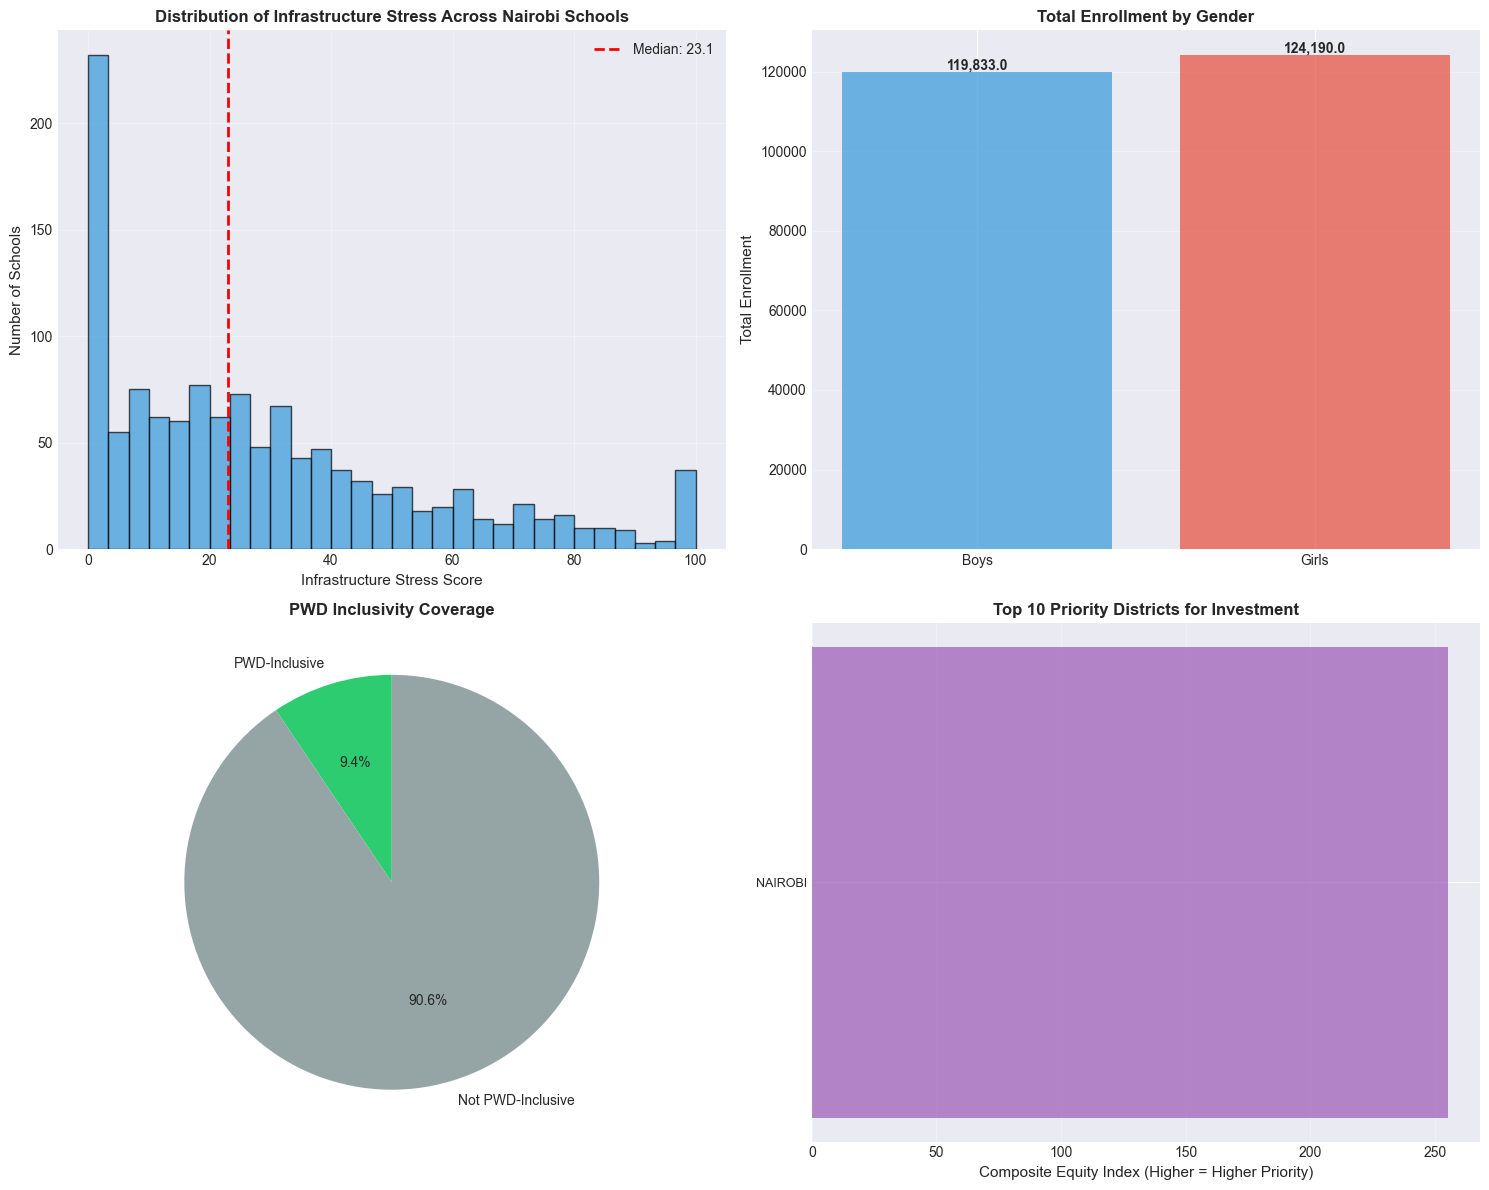

In [18]:
# Figure 1: Overview Analysis Dashboard
# Four-panel visualization showing key equity indicators
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel 1: Infrastructure Stress Distribution
axes[0, 0].hist(nairobi_schools_clean['Infrastructure_Stress'].dropna(), bins=30, 
                edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].axvline(nairobi_schools_clean['Infrastructure_Stress'].median(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f'Median: {nairobi_schools_clean["Infrastructure_Stress"].median():.1f}')
axes[0, 0].set_xlabel('Infrastructure Stress Score', fontsize=11)
axes[0, 0].set_ylabel('Number of Schools', fontsize=11)
axes[0, 0].set_title('Distribution of Infrastructure Stress Across Nairobi Schools', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Gender Enrollment Comparison
gender_data = [boys_enrollment, girls_enrollment]
axes[0, 1].bar(['Boys', 'Girls'], gender_data, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 1].set_ylabel('Total Enrollment', fontsize=11)
axes[0, 1].set_title('Total Enrollment by Gender', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(gender_data):
    axes[0, 1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Panel 3: PWD Inclusivity Coverage
pwd_counts = [nairobi_schools_clean['PWD_Inclusive'].sum(), 
              len(nairobi_schools_clean) - nairobi_schools_clean['PWD_Inclusive'].sum()]
axes[1, 0].pie(pwd_counts, labels=['PWD-Inclusive', 'Not PWD-Inclusive'], 
               autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#95a5a6'])
axes[1, 0].set_title('PWD Inclusivity Coverage', fontsize=12, fontweight='bold')

# Panel 4: Top Priority Districts
top_10 = equity_index.head(10)
axes[1, 1].barh(range(len(top_10)), top_10['Composite_Equity_Index'], color='#9b59b6', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(top_10['District'], fontsize=9)
axes[1, 1].set_xlabel('Composite Equity Index (Higher = Higher Priority)', fontsize=11)
axes[1, 1].set_title('Top 10 Priority Districts for Investment', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('nairobi_education_equity_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: nairobi_education_equity_analysis.png")
plt.show()


## 8. Key Findings

Summary of critical insights from the analysis.


In [19]:
# Generate comprehensive findings summary
print("="*80)
print("KEY FINDINGS: NAIROBI PRIMARY EDUCATION EQUITY ANALYSIS")
print("="*80)

print("\n1. INFRASTRUCTURE CAPACITY:")
print(f"   - Total schools analyzed: {len(nairobi_schools_clean):,}")
print(f"   - Schools with overcrowded classrooms (>50 ratio): {nairobi_schools_clean['Overcrowded_Classrooms'].sum():,} ({nairobi_schools_clean['Overcrowded_Classrooms'].sum()/len(nairobi_schools_clean)*100:.1f}%)")
print(f"   - Schools exceeding PTR standard (>40): {nairobi_schools_clean['High_PTR'].sum():,} ({nairobi_schools_clean['High_PTR'].sum()/len(nairobi_schools_clean)*100:.1f}%)")
print(f"   - Average infrastructure stress score: {nairobi_schools_clean['Infrastructure_Stress'].mean():.1f}/100")

print("\n2. GENDER EQUITY:")
print(f"   - Total enrollment: {total_enrollment:,}")
print(f"   - Girls enrollment: {girls_enrollment:,} ({girls_enrollment/total_enrollment*100:.1f}%)")
print(f"   - Boys enrollment: {boys_enrollment:,} ({boys_enrollment/total_enrollment*100:.1f}%)")
print(f"   - Schools with gender imbalance (>15% difference): {nairobi_schools_clean['Gender_Imbalance'].sum():,}")
print(f"   - Schools with girls' toilet deficit: {nairobi_schools_clean['Girls_Toilet_Deficit'].sum():,}")

print("\n3. PWD INCLUSIVITY:")
print(f"   - PWD-inclusive schools: {nairobi_schools_clean['PWD_Inclusive'].sum():,} ({pwd_coverage:.1f}%)")
print(f"   - Special schools: {len(special_schools):,}")
print(f"   - Integrated schools: {len(integrated_schools):,}")
print(f"   - Estimated PWD capacity gap: {pwd_capacity_gap:,.0f} children")

print("\n4. PRIORITY AREAS (Top 5 Districts by Composite Equity Index):")
for idx, row in equity_index.head(5).iterrows():
    print(f"   {row['Priority_Rank']}. {row['District']}: Index = {row['Composite_Equity_Index']:.1f}")
    print(f"      - Schools: {row['School_Count']}, Enrollment: {row['Total_Enrollment']:,}")
    print(f"      - Infrastructure Stress: {row['Avg_Infrastructure_Stress']:.1f}")
    print(f"      - PWD-inclusive schools: {row['PWD_Inclusive_Count']}")

print("\n" + "="*80)


KEY FINDINGS: NAIROBI PRIMARY EDUCATION EQUITY ANALYSIS

1. INFRASTRUCTURE CAPACITY:
   - Total schools analyzed: 1,241
   - Schools with overcrowded classrooms (>50 ratio): 97 (7.8%)
   - Schools exceeding PTR standard (>40): 124 (10.0%)
   - Average infrastructure stress score: 29.0/100

2. GENDER EQUITY:
   - Total enrollment: 335,056.0
   - Girls enrollment: 124,190.0 (37.1%)
   - Boys enrollment: 119,833.0 (35.8%)
   - Schools with gender imbalance (>15% difference): 135
   - Schools with girls' toilet deficit: 143

3. PWD INCLUSIVITY:
   - PWD-inclusive schools: 117 (9.4%)
   - Special schools: 16
   - Integrated schools: 101
   - Estimated PWD capacity gap: 0 children

4. PRIORITY AREAS (Top 5 Districts by Composite Equity Index):
   1. NAIROBI: Index = 255.3
      - Schools: 1241, Enrollment: 335,056.0
      - Infrastructure Stress: 29.0
      - PWD-inclusive schools: 117



## 9. Assumptions

All assumptions made during the analysis are explicitly documented here for transparency.


In [20]:
# Document all assumptions
assumptions = {
    "Data Recency": "Education facilities data is from 2013 but assumed representative for current analysis",
    "PWD Population": "Estimated PWD school-age population at 2.5% of total enrollment (conservative estimate based on global averages)",
    "Infrastructure Standards": {
        "Pupil-Teacher Ratio": "Kenya standard of 40:1 used as threshold",
        "Classroom Ratio": "50+ considered overcrowded",
        "Toilet Ratio": "50+ considered inadequate"
    },
    "Gender Equity": ">15% enrollment difference between genders considered significant imbalance",
    "Spatial Analysis": "District/Division used as proxy for sub-county level analysis where exact sub-county boundaries unavailable",
    "School Coordinates": "Schools with missing coordinates excluded from spatial analysis",
    "Composite Index Weights": {
        "School Density": "25%",
        "Infrastructure": "30%",
        "PWD Gap": "25%",
        "Gender Equity": "20%"
    }
}

print("ASSUMPTIONS DOCUMENTED:")
print("="*80)
for key, value in assumptions.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        for sub_key, sub_value in value.items():
            print(f"  - {sub_key}: {sub_value}")
    else:
        print(f"\n{key}: {value}")
print("\n" + "="*80)


ASSUMPTIONS DOCUMENTED:

Data Recency: Education facilities data is from 2013 but assumed representative for current analysis

PWD Population: Estimated PWD school-age population at 2.5% of total enrollment (conservative estimate based on global averages)

Infrastructure Standards:
  - Pupil-Teacher Ratio: Kenya standard of 40:1 used as threshold
  - Classroom Ratio: 50+ considered overcrowded
  - Toilet Ratio: 50+ considered inadequate

Gender Equity: >15% enrollment difference between genders considered significant imbalance

Spatial Analysis: District/Division used as proxy for sub-county level analysis where exact sub-county boundaries unavailable

School Coordinates: Schools with missing coordinates excluded from spatial analysis

Composite Index Weights:
  - School Density: 25%
  - Infrastructure: 30%
  - PWD Gap: 25%
  - Gender Equity: 20%



## 10. Recommendations

Actionable recommendations aligned with SDG 4 targets, prioritized by impact and feasibility.


In [21]:
# Generate actionable recommendations
print("="*80)
print("ACTIONABLE RECOMMENDATIONS FOR NAIROBI COUNTY EDUCATION OFFICER")
print("="*80)

print("\nPRIORITY 1: INFRASTRUCTURE CAPACITY BUILDING")
print("-" * 80)
print(f"• Target {nairobi_schools_clean['High_PTR'].sum():,} schools exceeding PTR standards")
print(f"• Construct additional classrooms in {nairobi_schools_clean['Overcrowded_Classrooms'].sum():,} overcrowded schools")
print("• Expand toilet facilities, with special attention to girls' facilities")
print(f"• Focus on top priority districts: {', '.join(equity_index.head(3)['District'].tolist())}")

print("\nPRIORITY 2: GENDER EQUITY INTERVENTIONS")
print("-" * 80)
print(f"• Address gender imbalance in {nairobi_schools_clean['Gender_Imbalance'].sum():,} schools")
print(f"• Improve girls' toilet facilities in {nairobi_schools_clean['Girls_Toilet_Deficit'].sum():,} schools")
print("• Implement targeted enrollment campaigns to balance gender representation")
print("• Ensure gender-responsive infrastructure in all new constructions")

print("\nPRIORITY 3: PWD INCLUSIVITY EXPANSION")
print("-" * 80)
print(f"• Expand PWD-inclusive capacity from current {nairobi_schools_clean['PWD_Inclusive'].sum():,} schools")
print(f"• Establish new integrated schools in districts with zero PWD coverage")
print(f"• Address capacity gap of approximately {pwd_capacity_gap:,.0f} PWD children")
print("• Retrofit existing schools with accessibility features (ramps, accessible toilets)")

print("\nPRIORITY 4: SPATIAL EQUITY")
print("-" * 80)
print("• Establish new schools in underserved high-density areas")
print("• Improve school distribution to reduce travel distances for students")
print("• Prioritize investments in districts with lowest school-to-population ratios")

print("\nALIGNMENT WITH SDG 4:")
print("-" * 80)
print("✓ Target 4.1: Free, equitable quality primary education")
print("✓ Target 4.5: Eliminate gender disparities and ensure equal access")
print("✓ Target 4.a: Build and upgrade education facilities that are disability-sensitive")
print("✓ Target 4.c: Increase supply of qualified teachers")

print("\n" + "="*80)


ACTIONABLE RECOMMENDATIONS FOR NAIROBI COUNTY EDUCATION OFFICER

PRIORITY 1: INFRASTRUCTURE CAPACITY BUILDING
--------------------------------------------------------------------------------
• Target 124 schools exceeding PTR standards
• Construct additional classrooms in 97 overcrowded schools
• Expand toilet facilities, with special attention to girls' facilities
• Focus on top priority districts: NAIROBI

PRIORITY 2: GENDER EQUITY INTERVENTIONS
--------------------------------------------------------------------------------
• Address gender imbalance in 135 schools
• Improve girls' toilet facilities in 143 schools
• Implement targeted enrollment campaigns to balance gender representation
• Ensure gender-responsive infrastructure in all new constructions

PRIORITY 3: PWD INCLUSIVITY EXPANSION
--------------------------------------------------------------------------------
• Expand PWD-inclusive capacity from current 117 schools
• Establish new integrated schools in districts with zer